# Import Modules

In [137]:
import pandas as pd
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# Connecting Python with MySQL Database

In [138]:
username = 'root'
password = 'root'
host = 'localhost'
db_name = 'food_delivery_analysis'

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}/{db_name}"
)

conn = engine.connect()

# Queries

### 1. Identify top-spending customers

In [139]:
query = """
SELECT
    Customer_ID,
    SUM(Final_Amount) as Total_Amount
FROM food_delivery
GROUP BY Customer_ID
ORDER BY Total_Amount DESC
LIMIT 10;
"""

result = conn.execute(text(query))

result_df = pd.DataFrame(result)

print(tabulate(
    result_df, 
    headers=result_df.columns, 
    tablefmt='grid'
    )
)

+----+---------------+----------------+
|    | Customer_ID   |   Total_Amount |
+====+===============+================+
|  0 | CUST1606      |        55866.9 |
+----+---------------+----------------+
|  1 | CUST4431      |        55717.4 |
+----+---------------+----------------+
|  2 | CUST5267      |        54700.3 |
+----+---------------+----------------+
|  3 | CUST5180      |        54448.7 |
+----+---------------+----------------+
|  4 | CUST1239      |        52932.4 |
+----+---------------+----------------+
|  5 | CUST5534      |        51797.4 |
+----+---------------+----------------+
|  6 | CUST8797      |        51423.8 |
+----+---------------+----------------+
|  7 | CUST3471      |        51143.5 |
+----+---------------+----------------+
|  8 | CUST8740      |        50762.4 |
+----+---------------+----------------+
|  9 | CUST2910      |        50592   |
+----+---------------+----------------+


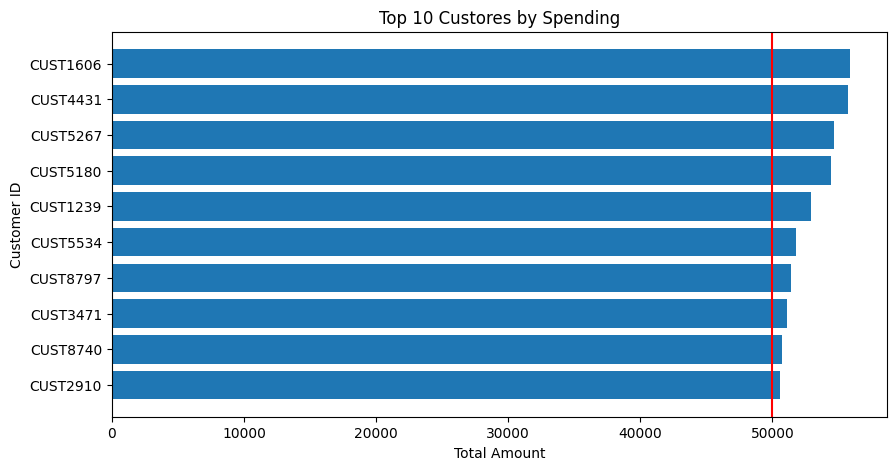

In [154]:
plt.figure(figsize=(10,5))

plt.barh(y=result_df["Customer_ID"], width=result_df["Total_Amount"])

plt.xlabel("Total Amount")
plt.ylabel("Customer ID")
plt.title("Top 10 Custores by Spending")

plt.gca().invert_yaxis()
plt.axvline(x=50000, color='red')

plt.show()

1. CUST1606 is the highest-spending customer with a total amount of 55,866.9.

2. All the top 10 customers spent more than 50,000.

### 2. Analyze age group vs order value

In [161]:
query = """
SELECT
    Cus_Age_Group as Age_Group,
    SUM(Order_Value) as Total_Amount
FROM food_delivery
GROUP BY Cus_Age_Group
ORDER BY Total_Amount DESC ;
"""

result = conn.execute(text(query))

result_df = pd.DataFrame(result)

result_df['Total_Amount'] = result_df['Total_Amount'].astype(int)

print(tabulate(
    result_df, 
    headers=result_df.columns, 
    tablefmt='grid'
    )
)

+----+-------------+----------------+
|    | Age_Group   |   Total_Amount |
+====+=============+================+
|  0 | Adult       |      153049083 |
+----+-------------+----------------+
|  1 | Yound       |       31358549 |
+----+-------------+----------------+
|  2 | Senior      |       23854917 |
+----+-------------+----------------+


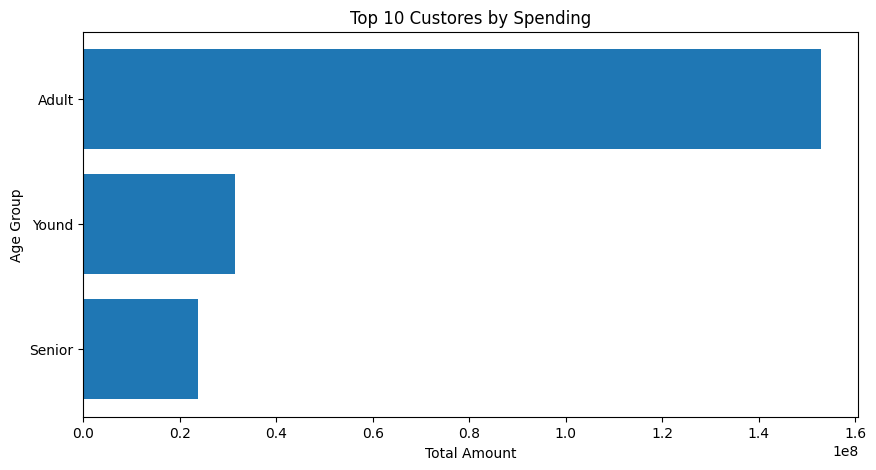

In [160]:
plt.figure(figsize=(10,5))

plt.barh(y=result_df["Age_Group"], width=result_df["Total_Amount"])

plt.xlabel("Total Amount")
plt.ylabel("Age Group")
plt.title("Top 10 Custores by Spending")

plt.gca().invert_yaxis()

plt.show()

1. Adults are the highest spenders with 153,049,083 total amount.

2. Young customers spend much less (31,358,549).

3. Seniors have the lowest spending (23,854,917).

### 3. Weekend vs Weekday order patterns

In [162]:
query = """
SELECT
    Order_Day,
    COUNT(*) as Total_Orders,
    sum(Order_Value) as Total_Amount,
    AVG(Order_Value) as Total_Average
FROM food_delivery
GROUP BY Order_Day
ORDER BY Order_Day;
"""

result = conn.execute(text(query))

result_df = pd.DataFrame(result)

result_df['Total_Amount'] = result_df['Total_Amount'].astype(int)

print(tabulate(
    result_df, 
    headers=result_df.columns, 
    tablefmt='grid'
    )
)

+----+-------------+----------------+----------------+-----------------+
|    | Order_Day   |   Total_Orders |   Total_Amount |   Total_Average |
+====+=============+================+================+=================+
|  0 | Weekday     |          71370 |      148800893 |         2084.92 |
+----+-------------+----------------+----------------+-----------------+
|  1 | Weekend     |          28630 |       59461656 |         2076.9  |
+----+-------------+----------------+----------------+-----------------+


Text(0.5, 1.0, 'Average Order Value')

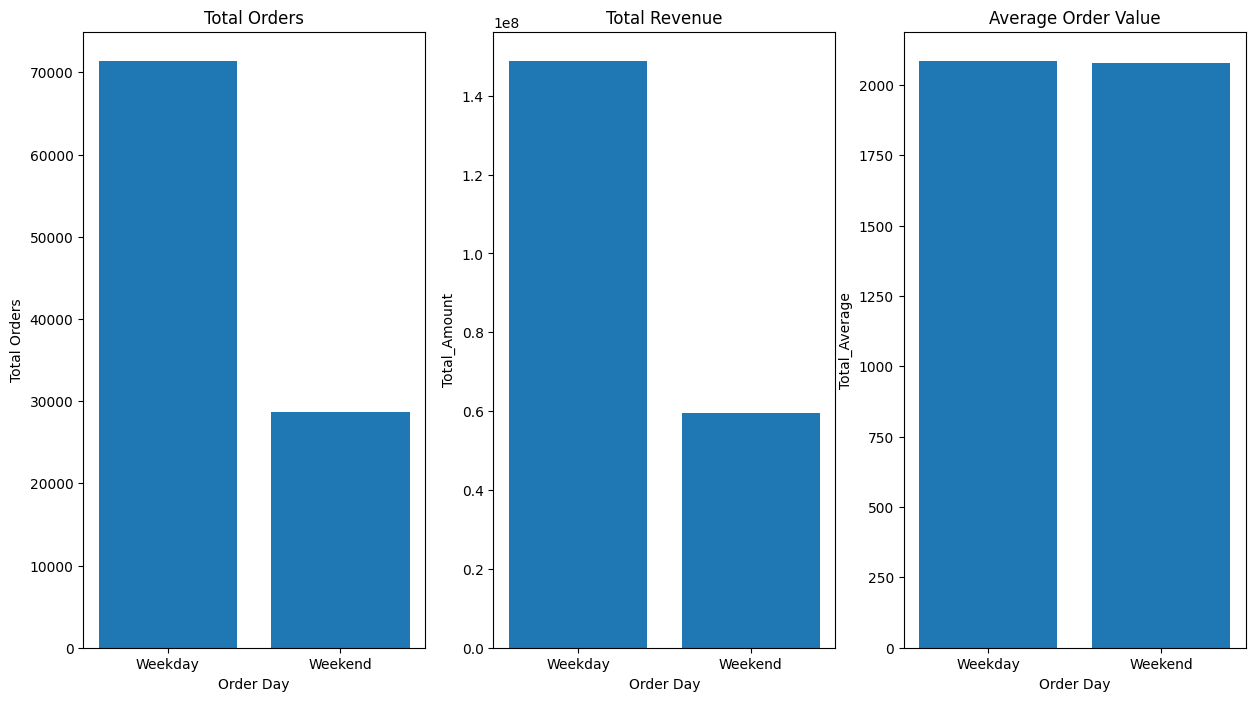

In [174]:
plt.figure(figsize=(15,8))


plt.subplot(1,3,1)
plt.bar(result_df["Order_Day"], result_df["Total_Orders"])
plt.xlabel("Order Day")
plt.ylabel("Total Orders")
plt.title("Total Orders")

plt.subplot(1,3,2)
plt.bar(result_df["Order_Day"], result_df["Total_Amount"])
plt.xlabel("Order Day")
plt.ylabel("Total_Amount")
plt.title("Total Revenue")

plt.subplot(1,3,3)
plt.bar(result_df["Order_Day"], result_df["Total_Average"])
plt.xlabel("Order Day")
plt.ylabel("Total_Average")
plt.title("Average Order Value")


1. Weekdays have more orders (71,370) compared to weekends (28,630).

2. Weekdays have a total revenue of 148,800,893 with an average order value of 2084.

3. Weekends have a total revenue of 59,461,656 with an average order value of 2076.

### 4. Monthly revenue trends

In [190]:
query = """
SELECT
    Ord_Month as Order_Month,
    count(*) as Total_Orders,
    SUM(Order_Value) as Total_Amount
FROM food_delivery
GROUP BY Ord_Month
ORDER BY Total_Amount DESC;
"""

result = conn.execute(text(query))

result_df = pd.DataFrame(result)

result_df['Total_Amount'] = result_df['Total_Amount'].astype(int)


print(tabulate(
    result_df, 
    headers=result_df.columns, 
    tablefmt='grid'
    )
)

+----+---------------+----------------+----------------+
|    |   Order_Month |   Total_Orders |   Total_Amount |
+====+===============+================+================+
|  0 |             7 |           8598 |       18097848 |
+----+---------------+----------------+----------------+
|  1 |             1 |           8617 |       17989207 |
+----+---------------+----------------+----------------+
|  2 |             5 |           8428 |       17716770 |
+----+---------------+----------------+----------------+
|  3 |             3 |           8481 |       17446271 |
+----+---------------+----------------+----------------+
|  4 |             9 |           8283 |       17380728 |
+----+---------------+----------------+----------------+
|  5 |             8 |           8341 |       17347798 |
+----+---------------+----------------+----------------+
|  6 |            10 |           8378 |       17284566 |
+----+---------------+----------------+----------------+
|  7 |             6 |         

Text(0.5, 1.0, 'Monthly Orders')

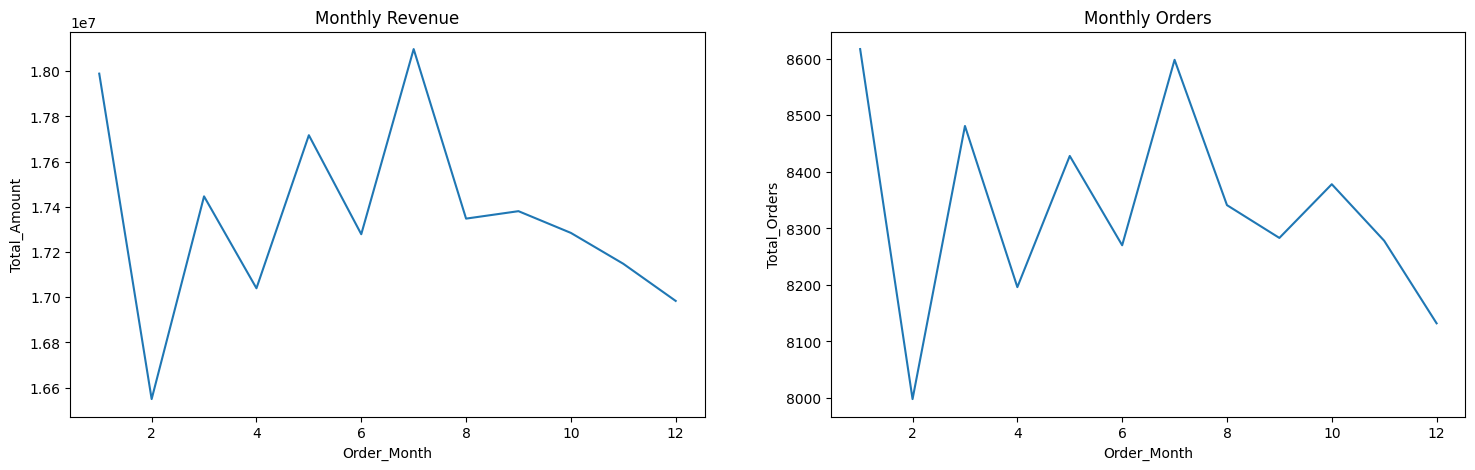

In [191]:
plt.figure(figsize=(18,5))

plt.subplot(1,2,1)
sns.lineplot(x=result_df["Order_Month"], y=result_df["Total_Amount"])
plt.title("Monthly Revenue")

plt.subplot(1,2,2)
sns.lineplot(x=result_df["Order_Month"], y=result_df["Total_Orders"])
plt.title("Monthly Orders")


1. July has the highest revenue with 18,097,848.

2. February has the lowest revenue with 16,549,358.

### 5. Impact of discounts on profit

In [125]:
query = """
SELECT
    Discount_Applied as Discount_amount,
    SUM(Final_Amount) as Total_Amount,
    sum((Final_Amount) * (Profit_Margin)) as Profit
FROM food_delivery
GROUP BY Discount_Applied
ORDER BY Total_Amount DESC;
"""

result = conn.execute(text(query))

result_df = pd.DataFrame(result)

result_df['Total_Amount'] = result_df['Total_Amount'].astype(int)
result_df['Profit'] = result_df['Profit'].astype(int)

print(tabulate(
    result_df, 
    headers=result_df.columns, 
    tablefmt='grid'
    )
)

+----+-------------------+----------------+----------+
|    |   Discount_amount |   Total_Amount |   Profit |
+====+===================+================+==========+
|  0 |                50 |       45107741 |  9301160 |
+----+-------------------+----------------+----------+
|  1 |                20 |       40084282 |  8244128 |
+----+-------------------+----------------+----------+
|  2 |               100 |       39400484 |  8227356 |
+----+-------------------+----------------+----------+
|  3 |                 0 |       35587812 |  7374679 |
+----+-------------------+----------------+----------+
|  4 |               300 |       30522137 |  6339828 |
+----+-------------------+----------------+----------+
|  5 |                35 |        2712008 |   567446 |
+----+-------------------+----------------+----------+
|  6 |                75 |        2504712 |   513136 |
+----+-------------------+----------------+----------+
|  7 |                60 |         857403 |   168152 |
+----+----

1. Medium discounts (20, 50, and 100) generate the highest revenue and profit.

2. No discount (0) still produces strong revenue and profit.

3. Very high discounts (like 300) result in lower revenue and profit compared to no discount.

### 6. High-revenue cities and cuisines

In [126]:
query = """
SELECT
    City,
    Cuisine_Type,
    SUM(Final_Amount) as Total_Amount,
    COUNT(*) as Total_Orders
FROM food_delivery
GROUP BY City, Cuisine_Type
ORDER BY Total_Orders DESC
LIMIT 5;
"""

result = conn.execute(text(query))

result_df = pd.DataFrame(result)

result_df['Total_Amount'] = result_df['Total_Amount'].astype(int)

print(tabulate(
    result_df, 
    headers=result_df.columns, 
    tablefmt='grid'
    )
)

+----+-----------+----------------+----------------+----------------+
|    | City      | Cuisine_Type   |   Total_Amount |   Total_Orders |
+====+===========+================+================+================+
|  0 | Hyderabad | Arabian        |        8774466 |           4388 |
+----+-----------+----------------+----------------+----------------+
|  1 | Delhi     | Arabian        |        8447580 |           4339 |
+----+-----------+----------------+----------------+----------------+
|  2 | Bangalore | Chinese        |        8306327 |           4222 |
+----+-----------+----------------+----------------+----------------+
|  3 | Hyderabad | Chinese        |        8304397 |           4202 |
+----+-----------+----------------+----------------+----------------+
|  4 | Bangalore | Indian         |        8500978 |           4202 |
+----+-----------+----------------+----------------+----------------+


1. Hyderabad - Arabian cuisine generates the highest revenue 8,774,466 with the most orders 4388.

2. Delhi - Arabian cuisine is also generates the strong revenue 8,447,580 with the most orders 4339.

3. In Bangalore, both Chinese and Indian cuisines perform well.

### 7. Average delivery time by city

In [194]:
query = """
SELECT
    City,
    AVG(Delivery_Time_Min) as Average_Delivery_Time
FROM food_delivery
GROUP BY City
ORDER BY Average_Delivery_Time;
"""

result = conn.execute(text(query))

result_df = pd.DataFrame(result)

print(tabulate(
    result_df, 
    headers=result_df.columns, 
    tablefmt='grid'
    )
)

+----+-----------+-------------------------+
|    | City      |   Average_Delivery_Time |
+====+===========+=========================+
|  0 | Bangalore |                 119.924 |
+----+-----------+-------------------------+
|  1 | Delhi     |                 120.939 |
+----+-----------+-------------------------+
|  2 | Hyderabad |                 121.002 |
+----+-----------+-------------------------+
|  3 | Chennai   |                 121.103 |
+----+-----------+-------------------------+
|  4 | Mumbai    |                 122.999 |
+----+-----------+-------------------------+


1. Bangalore has the most fastest delivery time (119.9).

2. All the cities have the similar delivery time (~120).

### 8. Distance vs Delivery delay analysis

In [128]:
query = """
SELECT
    CASE
        WHEN Distance_km BETWEEN 0 and 1 THEN '0-2 KM'
        WHEN Distance_km BETWEEN 2 and 5 THEN '2-5 KM'
        WHEN Distance_km BETWEEN 5 and 10 THEN '5-10 KM'
        WHEN Distance_km BETWEEN 10 and 15 THEN '10-15 KM'
        WHEN Distance_km BETWEEN 15 and 20 THEN '15-20 KM'
        WHEN Distance_km BETWEEN 20 and 25 THEN '20-25 KM'
        WHEN Distance_km BETWEEN 25 and 30 THEN '25-30 KM'
        WHEN Distance_km BETWEEN 30 and 35 THEN '30-35 KM'
        WHEN Distance_km BETWEEN 35 and 40 THEN '35-40 KM'
        ELSE '40+ KM'
        END as Distance_Range,
    COUNT(*) as Total_Orders,
    AVG(Delivery_Time_Min) as Average_Time
FROM food_delivery
GROUP BY Distance_Range
ORDER BY Total_Orders DESC;
"""

result = conn.execute(text(query))

result_df = pd.DataFrame(result)

print(tabulate(
    result_df, 
    headers=result_df.columns, 
    tablefmt='grid'
    )
)

+----+------------------+----------------+----------------+
|    | Distance_Range   |   Total_Orders |   Average_Time |
+====+==================+================+================+
|  0 | 5-10 KM          |          22076 |        121.33  |
+----+------------------+----------------+----------------+
|  1 | 15-20 KM         |          18439 |        121.1   |
+----+------------------+----------------+----------------+
|  2 | 20-25 KM         |          12398 |        121.498 |
+----+------------------+----------------+----------------+
|  3 | 2-5 KM           |          11962 |        120.376 |
+----+------------------+----------------+----------------+
|  4 | 10-15 KM         |           8933 |        121.045 |
+----+------------------+----------------+----------------+
|  5 | 25-30 KM         |           8494 |        121.529 |
+----+------------------+----------------+----------------+
|  6 | 30-35 KM         |           7122 |        122.523 |
+----+------------------+---------------

1. Most orders happend from 5-10 KM range 22076.

2. Delivery time stays almost constant (~120 Min) across all distance.

### 9. Delivery rating vs delivery time

In [129]:
query = """
SELECT
    CASE
        WHEN Delivery_Time_Min BETWEEN 0 AND 20 THEN '0-20 Min'
        WHEN Delivery_Time_Min BETWEEN 20 AND 40 THEN '20-40 Min'
        WHEN Delivery_Time_Min BETWEEN 40 AND 60 THEN '40-60 Min'
        ELSE '60+ Min'
        END AS Time_Period,
    COUNT(*) as Total_Orders,
    AVG(Delivery_Rating) as Average_Rating
FROM food_delivery
GROUP BY Time_Period
ORDER BY Time_Period;
"""

result = conn.execute(text(query))

result_df = pd.DataFrame(result)

print(tabulate(
    result_df, 
    headers=result_df.columns, 
    tablefmt='grid'
    )
)

+----+---------------+----------------+------------------+
|    | Time_Period   |   Total_Orders |   Average_Rating |
+====+===============+================+==================+
|  0 | 0-20 Min      |            657 |           2.4658 |
+----+---------------+----------------+------------------+
|  1 | 20-40 Min     |          13445 |           2.4543 |
+----+---------------+----------------+------------------+
|  2 | 40-60 Min     |          19077 |           2.4822 |
+----+---------------+----------------+------------------+
|  3 | 60+ Min       |          66821 |           2.4592 |
+----+---------------+----------------+------------------+


1. Most orders are delivered in 60+ minutes (66,821 orders).

2. Average rating is almost constant (~2.5) across all delivery time ranges.

3. Very fast deliveries (0–20 minutes) are very rare.

### 10. Top-rated restaurants

In [130]:
query = """
SELECT
    Restaurant_Name,
    Restaurant_Rating
FROM food_delivery
ORDER BY Restaurant_Rating DESC
LIMIT 5;
"""

result = conn.execute(text(query))

result_df = pd.DataFrame(result)

print(tabulate(
    result_df, 
    headers=result_df.columns, 
    tablefmt='grid'
    )
)

+----+-------------------+---------------------+
|    | Restaurant_Name   |   Restaurant_Rating |
+====+===================+=====================+
|  0 | Restaurant_66     |                   5 |
+----+-------------------+---------------------+
|  1 | Restaurant_154    |                   5 |
+----+-------------------+---------------------+
|  2 | Restaurant_43     |                   5 |
+----+-------------------+---------------------+
|  3 | Restaurant_227    |                   5 |
+----+-------------------+---------------------+
|  4 | Restaurant_189    |                   5 |
+----+-------------------+---------------------+


1. All the top 5 Restaurant have a perfect rating of 5.

2. Restaurant_66, Restaurant_154, Restaurant_43, Restaurant_227 and Restaurant_189.

### 11. Cancellation rate by restaurant

In [198]:
query = """
SELECT
    Restaurant_ID,
    COUNT(*) as Total_Cancelled_Orders
FROM food_delivery
WHERE Order_Status = "Cancelled"
GROUP BY Order_Status, Restaurant_ID
ORDER BY Total_Cancelled_Orders DESC
LIMIT 5;
"""

result = conn.execute(text(query))

result_df = pd.DataFrame(result)

print(tabulate(
    result_df, 
    headers=result_df.columns, 
    tablefmt='grid'
    )
)

+----+-----------------+--------------------------+
|    | Restaurant_ID   |   Total_Cancelled_Orders |
+====+=================+==========================+
|  0 | RES117          |                       30 |
+----+-----------------+--------------------------+
|  1 | RES594          |                       30 |
+----+-----------------+--------------------------+
|  2 | RES770          |                       28 |
+----+-----------------+--------------------------+
|  3 | RES591          |                       28 |
+----+-----------------+--------------------------+
|  4 | RES384          |                       28 |
+----+-----------------+--------------------------+


1. RES914 and RES715 have the highest cancellations with 30 orders each.

2. RES770, RES591 and RES384 also show high cancellation of 28 orders each.

### 12. Cuisine-wise performance

In [199]:
query = """
SELECT
    Cuisine_Type,
    COUNT(*) as Total_Orders,
    SUM(Final_Amount) as Total_Amount,
    AVG(Final_Amount) as Average_Amount
FROM food_delivery
GROUP BY Cuisine_Type
ORDER BY Total_Amount DESC ;
"""

result = conn.execute(text(query))

result_df = pd.DataFrame(result)
result_df['Total_Amount'] = result_df['Total_Amount'].astype(int)

print(tabulate(
    result_df, 
    headers=result_df.columns, 
    tablefmt='grid'
    )
)

+----+----------------+----------------+----------------+------------------+
|    | Cuisine_Type   |   Total_Orders |   Total_Amount |   Average_Amount |
+====+================+================+================+==================+
|  0 | Arabian        |          21192 |       42098070 |          1986.51 |
+----+----------------+----------------+----------------+------------------+
|  1 | Chinese        |          20389 |       40730709 |          1997.68 |
+----+----------------+----------------+----------------+------------------+
|  2 | Indian         |          19763 |       39456837 |          1996.5  |
+----+----------------+----------------+----------------+------------------+
|  3 | Italian        |          19511 |       38912525 |          1994.39 |
+----+----------------+----------------+----------------+------------------+
|  4 | Mexican        |          19145 |       38141476 |          1992.24 |
+----+----------------+----------------+----------------+------------------+

1. Arabian cuisian has the most frequest order by the customers with 21192 total orders and total revenue 42,098,079.

2. Chinese and Indian cuisines also have very close revenue and total orders.

3. Average order value is almost the same around 1990 across all cuisines.

### 13. Peak hour demand analysis

In [133]:
query = """
SELECT
    Peak_Hour,
    COUNT(*) as Total_Orders
FROM food_delivery
GROUP BY Peak_Hour
ORDER BY Total_Orders DESC;
"""

result = conn.execute(text(query))

result_df = pd.DataFrame(result)

peak_hour_map = {
    0:'No', 
    1:'Yes'
}

result_df['Peak_Hour'] = result_df['Peak_Hour'].map(peak_hour_map)



print(tabulate(
    result_df, 
    headers=result_df.columns, 
    tablefmt='grid'
    )
)

+----+-------------+----------------+
|    | Peak_Hour   |   Total_Orders |
+====+=============+================+
|  0 | No          |          50154 |
+----+-------------+----------------+
|  1 | Yes         |          49846 |
+----+-------------+----------------+


1. Non peak hours slightly have more orders compared to peak hours.

2. Order distribution is almost equal between peak and non peak hours.

### 14. Payment mode preferences

In [134]:
query = """
SELECT
    Payment_Mode,
    COUNT(*) as Total_Orders,
    sum(Final_Amount) as Total_Amount,
    AVG(Final_Amount) as Average_Amount
FROM food_delivery
GROUP BY Payment_Mode
ORDER BY Total_Orders DESC;
"""

result = conn.execute(text(query))

result_df = pd.DataFrame(result)

result_df['Total_Amount'] = result_df['Total_Amount'].astype(int)

print(tabulate(
    result_df, 
    headers=result_df.columns, 
    tablefmt='grid'
    )
)

+----+----------------+----------------+----------------+------------------+
|    | Payment_Mode   |   Total_Orders |   Total_Amount |   Average_Amount |
+====+================+================+================+==================+
|  0 | Wallet         |          27937 |       55473121 |          1985.65 |
+----+----------------+----------------+----------------+------------------+
|  1 | Card           |          24787 |       49139527 |          1982.47 |
+----+----------------+----------------+----------------+------------------+
|  2 | UPI            |          24641 |       49538655 |          2010.42 |
+----+----------------+----------------+----------------+------------------+
|  3 | COD            |          22635 |       45188315 |          1996.39 |
+----+----------------+----------------+----------------+------------------+


1. Wallet is the most used payment method by the customer and generates highest total revenue.

2. Card and UPI have very close total orders and revenue, and UPI has the highest average order value.

### 15. Cancellation Reason analysis

In [135]:
query = """
SELECT
    Cancellation_Reason,
    COUNT(*) as Total_Orders
FROM food_delivery
GROUP BY Cancellation_Reason
ORDER BY Total_Orders DESC
LIMIT 3 OFFSET 1;
"""

result = conn.execute(text(query))

result_df = pd.DataFrame(result)

print(tabulate(
    result_df, 
    headers=result_df.columns, 
    tablefmt='grid'
    )
)

+----+-----------------------+----------------+
|    | Cancellation_Reason   |   Total_Orders |
+====+=======================+================+
|  0 | Late Delivery         |           5984 |
+----+-----------------------+----------------+
|  1 | Restaurant Issue      |           4908 |
+----+-----------------------+----------------+
|  2 | Customer Cancelled    |           4144 |
+----+-----------------------+----------------+


1. Most of the customer cancelled the orders beacuse of the late delivery (5984).

2. Restaurant related issue comes next(4908).

# Terminating Connection

In [136]:
conn.close()